In [2]:
!pip install ucimlrepo -q
!pip install scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix,
    ConfusionMatrixDisplay)



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 628.6 kB/s eta 0:00:13
   ----- ---------------------------------- 1.0/8.1 MB 1.2 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.1 MB 1.6 MB/s eta 0:00:05
   ---------- ----------------------------- 2.1/8.1 MB 1.8 MB/s eta 0:00:04
   ------------ --------------------------- 2.6/8.1 MB 1.9 MB/s eta 0:00:03
   ---------------- ----------------------- 3.4/8.1 MB 2.1 MB/s eta 0:00:03
   ------------------- -------------------- 3.9/8.1 MB 2.2 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/8.1 MB 2.2 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.1 MB 2.3 MB/s eta 0:00:02
   ---------------------------- ----------- 5.8/8.1 MB 2.4 MB/s eta 0:00:01
   ----------------------------

In [3]:
ionosphere = fetch_ucirepo(id=52)
X_raw = ionosphere.data.features
y_raw = ionosphere.data.targets

print("Shape dos atributos:", X_raw.shape)
print("\nDistribuição das classes:")
print(y_raw.value_counts())
X_raw.head()

Shape dos atributos: (351, 34)

Distribuição das classes:
Class
g        225
b        126
Name: count, dtype: int64


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute25,Attribute26,Attribute27,Attribute28,Attribute29,Attribute30,Attribute31,Attribute32,Attribute33,Attribute34
0,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,0.56811,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300
1,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.20332,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447
2,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,0.57528,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238
3,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,1.00000,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000
4,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,0.03286,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697


In [4]:

y = np.where(y_raw.values.ravel() == 'g', 1, -1)
X = X_raw.values.copy()

print("Classes únicas após recodificação:", np.unique(y))
print(f"  +1 (good): {(y ==  1).sum()} amostras")
print(f"  -1 (bad) : {(y == -1).sum()} amostras")

Classes únicas após recodificação: [-1  1]
  +1 (good): 225 amostras
  -1 (bad) : 126 amostras


In [5]:
df = pd.DataFrame(X, columns=X_raw.columns)

missing = df.isnull().sum().sum()
print(f"Valores ausentes: {missing}")

zero_var = df.columns[df.std() == 0].tolist()
print(f"Atributos constantes (variância = 0): {zero_var}")

if zero_var:
    df.drop(columns=zero_var, inplace=True)
    X = df.values
    print(f"→ Removidos. Novo shape: {X.shape}")
else:
    print("→ Nenhum atributo constante. Shape mantido:", X.shape)

Valores ausentes: 0
Atributos constantes (variância = 0): ['Attribute2']
→ Removidos. Novo shape: (351, 33)


In [6]:
modelos = {}
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Amostras de treino : {X_train.shape[0]}")
print(f"Amostras de teste  : {X_test.shape[0]}")
print(f"Atributos          : {X_train.shape[1]}")
print(f"\nDistribuição no treino → +1: {(y_train==1).sum()}  | -1: {(y_train==-1).sum()}")
print(f"Distribuição no teste  → +1: {(y_test ==1).sum()}  | -1: {(y_test ==-1).sum()}")

Amostras de treino : 280
Amostras de teste  : 71
Atributos          : 33

Distribuição no treino → +1: 179  | -1: 101
Distribuição no teste  → +1: 46  | -1: 25


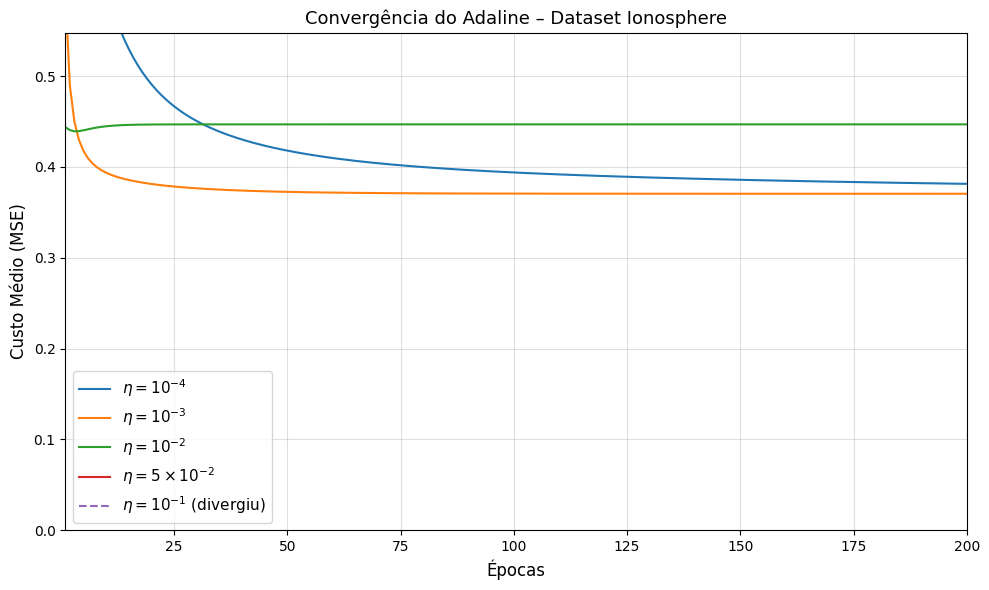


Custo final (última época):
  $\eta = 10^{-4}$                      : 0.381300
  $\eta = 10^{-3}$                      : 0.370371
  $\eta = 10^{-2}$                      : 0.446786
  $\eta = 5\times10^{-2}$               : divergiu
  $\eta = 10^{-1}$                      : divergiu


In [9]:
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import mean_squared_error
warnings.filterwarnings('ignore', category=ConvergenceWarning)

N_EPOCHS   = 200
SEED       = 42
taxas      = [1e-4, 1e-3, 1e-2, 5e-2, 1e-1]
labels_eta = [r'$\eta = 10^{-4}$', r'$\eta = 10^{-3}$',
              r'$\eta = 10^{-2}$', r'$\eta = 5\times10^{-2}$',
              r'$\eta = 10^{-1}$']

modelos    = {}
historicos = {}

for eta, label in zip(taxas, labels_eta):
    model  = SGDClassifier(loss='squared_error', eta0=eta,
                           learning_rate='constant', max_iter=1,
                           warm_start=True, shuffle=True, random_state=SEED)
    custos = []
    for _ in range(N_EPOCHS):
        model.fit(X_train, y_train)
        u   = model.decision_function(X_train)
        mse = mean_squared_error(y_train, u)
        custos.append(mse if np.isfinite(mse) and mse < 1e6 else np.nan)

    modelos[label]    = model
    historicos[label] = np.array(custos)

valores_finitos = [c for custos in historicos.values()
                   for c in custos if np.isfinite(c)]
ymax = np.percentile(valores_finitos, 95) * 1.2

fig, ax = plt.subplots(figsize=(10, 6))
epochs = range(1, N_EPOCHS + 1)
for label, custos in historicos.items():
    c = np.array(custos, dtype=np.float64)
    c[~np.isfinite(c)] = np.nan
    if np.all(np.isnan(c)):
        ax.plot([], [], linestyle='--', label=label + ' (divergiu)')
    else:
        ax.plot(epochs, c, label=label)

ax.set_ylim(0, ymax)
ax.set_xlabel('Épocas', fontsize=12)
ax.set_ylabel('Custo Médio (MSE)', fontsize=12)
ax.set_title('Convergência do Adaline – Dataset Ionosphere', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim([1, N_EPOCHS])
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print("\nCusto final (última época):")
for label, custos in historicos.items():
    ultimo = custos[-1]
    print(f"  {label:38s}: {'divergiu' if np.isnan(ultimo) else f'{ultimo:.6f}'}")

Melhor η: $\eta = 10^{-3}$  (η = 0.001)
Custo final: 0.370371


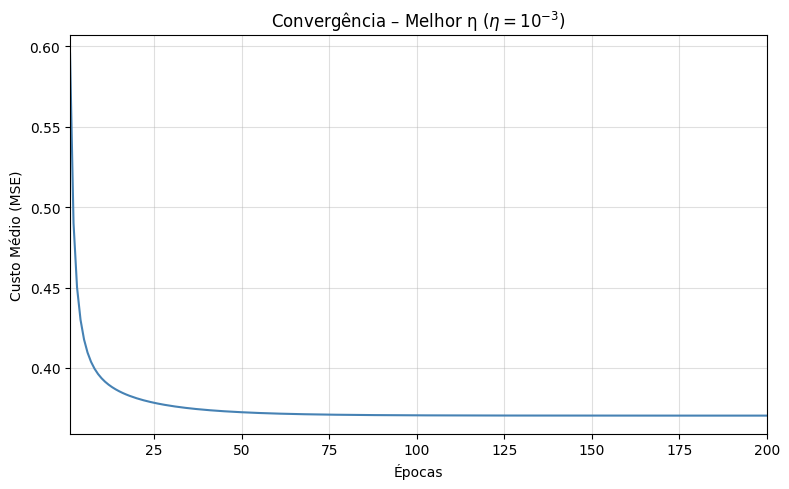

In [10]:

custos_finais = {label: custos[-1] for label, custos in historicos.items()
                 if np.isfinite(custos[-1])}

melhor_label = min(custos_finais, key=custos_finais.get)
melhor_eta   = taxas[labels_eta.index(melhor_label)]

print(f"Melhor η: {melhor_label}  (η = {melhor_eta})")
print(f"Custo final: {custos_finais[melhor_label]:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(epochs, historicos[melhor_label], color='steelblue')
plt.xlabel('Épocas')
plt.ylabel('Custo Médio (MSE)')
plt.title(f'Convergência – Melhor η ({melhor_label})')
plt.xlim([1, N_EPOCHS])
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [11]:
adaline_sklearn = SGDClassifier(
    loss='squared_error',
    eta0=melhor_eta,
    learning_rate='constant',
    max_iter=N_EPOCHS,
    shuffle=True,
    random_state=SEED
)
adaline_sklearn.fit(X_train, y_train)
y_pred_sklearn = adaline_sklearn.predict(X_test)

cm_sk = confusion_matrix(y_test, y_pred_sklearn, labels=[-1, 1])
print("Matriz de Confusão (sklearn):")
print(cm_sk)

Matriz de Confusão (sklearn):
[[22  3]
 [ 0 46]]


In [12]:
print("=== Métricas – Adaline sklearn ===")
print(f"Acurácia  : {accuracy_score(y_test, y_pred_sklearn):.4f}")
print(f"Precisão  : {precision_score(y_test, y_pred_sklearn, pos_label=1):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_sklearn, pos_label=1):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_sklearn, pos_label=1):.4f}")

=== Métricas – Adaline sklearn ===
Acurácia  : 0.9577
Precisão  : 0.9388
Recall    : 1.0000
F1-Score  : 0.9684
